# Support Information Figures

Follow through this notebook you can reproduce all the figures presented in the paper

In [114]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import gaussian_kde

# Plotting and Styling
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Machine Learning and Evaluation
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_fscore_support, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Recurrent Neural Networks
from dataclasses import dataclass
import json
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

### Figure S1. Dataset Construction and Spliting Details for GBC training

In [2]:
# Set global font and style for all plots
def _set_global_font():
    """Helper to enforce Arial Bold, size 8 everywhere."""
    rc('axes', linewidth=1)

    plt.rcParams['pdf.fonttype'] = 42   # Embed fonts as Truetype → editable text
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 8
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 8
    plt.rcParams['axes.labelsize'] = 8

    plt.rc('xtick', labelsize=8)
    plt.rc('ytick', labelsize=8)
    plt.rc('legend', fontsize=8)
    plt.rcParams['legend.title_fontsize'] = 8
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.top'] = True
    plt.rcParams['ytick.right'] = True
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.8
    plt.rcParams['ytick.major.width'] = 0.8

In [ ]:
data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'dataset_test_no_norm.pkl')

with open(data_path, 'rb') as f:
    X, labels_tst = pickle.load(f)

y_data = np.array(labels_tst)
total_easy = len(np.where(y_data == 0)[0])
total_difficult = len(np.where(y_data == 1)[0])

iSmall_total = 2000
iMedium_total = 10000
iLarge_total = 20000

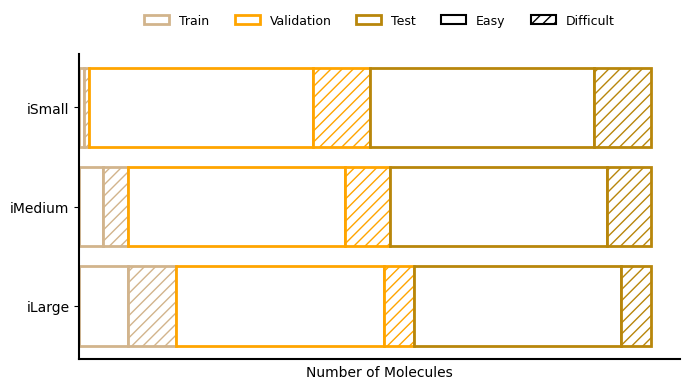

In [ ]:
# The y-axis categories
datasets = ['iLarge', 'iMedium', 'iSmall']

train_counts = np.array([iLarge_total, iMedium_total, iSmall_total])
val_counts   = np.array([(len(y_data) - iLarge_total)/2, (len(y_data) - iMedium_total)/2, (len(y_data) - iSmall_total)/2])
test_counts  = np.array([(len(y_data) - iLarge_total)/2, (len(y_data) - iMedium_total)/2, (len(y_data) - iSmall_total)/2])

train_difficult_ratio = np.array([0.5, 0.5, 0.5])  
val_difficult_ratio   = np.array([(total_difficult - iLarge_total/2)/len(y_data), (total_difficult - iMedium_total/2)/len(y_data), (total_difficult - iSmall_total/2)/len(y_data)]) 
test_difficult_ratio  = np.array([(total_difficult - iLarge_total/2)/len(y_data), (total_difficult - iMedium_total/2)/len(y_data), (total_difficult - iSmall_total/2)/len(y_data)])  

train_difficult = train_counts * train_difficult_ratio
train_easy = train_counts - train_difficult

val_difficult = val_counts * val_difficult_ratio
val_easy = val_counts - val_difficult

test_difficult = test_counts * test_difficult_ratio
test_easy = test_counts - test_difficult

color_train = 'tan' # Tan
color_val   = 'orange'
color_test  = 'darkgoldenrod'

fig, ax = plt.subplots(figsize=(7, 4))

# 1. TRAIN SECTION
# Train - easy (Starts at 0, Hollow)
ax.barh(datasets, train_easy, 
        color='white', edgecolor=color_train, linewidth=2)
# Train - difficult (Starts after Train-easy, Hatched)
ax.barh(datasets, train_difficult, left=train_easy, 
        color='white', edgecolor=color_train, hatch='///', linewidth=2)

# 2. VALIDATION SECTION
# Val - easy (Starts after total Train, Hollow)
ax.barh(datasets, val_easy, left=train_counts, 
        color='white', edgecolor=color_val, linewidth=2)
# Val - difficult (Starts after Train + Val-easy, Hatched)
ax.barh(datasets, val_difficult, left=(train_counts + val_easy), 
        color='white', edgecolor=color_val, hatch='///', linewidth=2)

# 3. TEST SECTION
# Test - easy (Starts after total Train + total Val, Hollow)
ax.barh(datasets, test_easy, left=(train_counts + val_counts), 
        color='white', edgecolor=color_test, linewidth=2)
# Test - difficult (Starts after Train + Val + Test-easy, Hatched)
ax.barh(datasets, test_difficult, left=(train_counts + val_counts + test_easy), 
        color='white', edgecolor=color_test, hatch='///', linewidth=2)

# Formatting & Legend 
ax.set_xlabel("Number of Molecules")
ax.set_xticks([])

# Clean up the borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Custom legend to explain both Colors (Splits) and Patterns (Classes)
legend_elements = [
    Patch(facecolor='white', edgecolor=color_train, linewidth=2, label='Train'),
    Patch(facecolor='white', edgecolor=color_val, linewidth=2, label='Validation'),
    Patch(facecolor='white', edgecolor=color_test, linewidth=2, label='Test'),
    Patch(facecolor='white', edgecolor='black', linewidth=1.5, label='Easy'),
    Patch(facecolor='white', edgecolor='black', hatch='///', linewidth=1.5, label='Difficult')
]

# Place legend centered above the chart
ax.legend(handles=legend_elements, frameon=False, loc='lower center', 
          bbox_to_anchor=(0.5, 1.05), ncol=5, fontsize=9)

plt.tight_layout()
plt.savefig('Figure_S1_main.pdf', bbox_inches='tight', format='pdf', dpi=600)
plt.show()

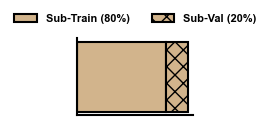

In [15]:
# Calculate the 80/20 split
sub_train_count = iLarge_total * 0.80  # 16,000
sub_val_count   = iLarge_total * 0.20  # 4,000

_set_global_font()

fig, ax = plt.subplots(figsize=(1.5, 1))

# --- 3. Plotting the Sub-divided Bar ---
# Part 1: Sub-Train (80% Solid Tan)
ax.barh(['Training Set'], sub_train_count, 
        color='tan', edgecolor='black', linewidth=1.5, 
        label='Sub-Train (80%)')

# Part 2: Sub-Val (20% Hatched with 'XX')
# The 'left' parameter makes it start exactly where sub_train ended
ax.barh(['Training Set'], sub_val_count, left=sub_train_count, 
        color='tan', edgecolor='black', hatch='XX', linewidth=1.5, 
        label='Sub-Val (20%)')

ax.set_xticks([])  
ax.set_yticks([])  

# Clean up the borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Add standard legend
ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.savefig('Figure_S1_bottom.pdf', bbox_inches='tight', format='pdf', dpi=600)
plt.show()

### Figure S2. Baseline Performance Comparison of Four Machine Learning Classifiers

In [17]:
data_path = os.path.join(Path.cwd().parents[0], 'Data', 'feature_sets', 'iSmall_train.csv')
iSmall_df = pd.read_csv(data_path)

x_data = iSmall_df.drop(columns=['label']).values
y_data = iSmall_df['label'].values

model_rc = RidgeClassifier(random_state=42)
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_rf = RandomForestClassifier(max_depth=3, random_state=42)
model_gb = GradientBoostingClassifier(max_depth=3, random_state=42)

In [18]:
def get_results(x_data, y_data, model_s):
    tprs = []
    aucs = []
    f1s = [] # Track F1 for each fold
    mean_fpr = np.linspace(0, 1, 100) # Common grid for interpolation

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(x_data):
        X_train, X_test = x_data[train_index], x_data[test_index]
        y_train, y_test = y_data[train_index], y_data[test_index]

        min_max_scaler = MinMaxScaler() 
        min_max_scaler.fit(X_train)   

        model_s.fit(X_train, y_train)
        
        X_test_scaled = min_max_scaler.transform(X_test)
        y_pred = model_s.predict(X_test_scaled)
        f1s.append(accuracy_score(y_test, y_pred))

        # Handle Ridge/SVM vs Probabilistic models
        if hasattr(model_s, "predict_proba"):
            scores = model_s.predict_proba(X_test)[:, 1]
        else:
            scores = model_s.decision_function(X_test)

        fpr, tpr, thresholds = roc_curve(y_test, scores)
        
        # Interpolate this fold's TPR onto the common FPR grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0 # Force start at 0
        tprs.append(interp_tpr)
        
        aucs.append(auc(fpr, tpr))

    return mean_fpr, tprs, aucs, f1s

In [21]:
mean_fpr_rc, tprs_rc, aucs_rc, f1s_rc= get_results(x_data, y_data, model_rc)
mean_fpr_dt, tprs_dt, aucs_dt, f1s_dt = get_results(x_data, y_data, model_dt)
mean_fpr_rf, tprs_rf, aucs_rf, f1s_rf = get_results(x_data, y_data, model_rf)
mean_fpr_gb, tprs_gb, aucs_gb, f1s_gb = get_results(x_data, y_data, model_gb)

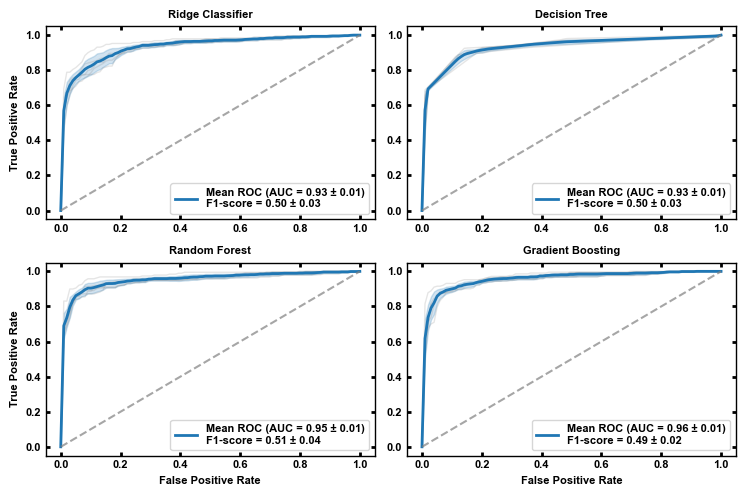

In [23]:
_set_global_font()

fig, axes = plt.subplots(2, 2, figsize=(7.5, 5))
models_data = [
    (mean_fpr_rc, tprs_rc, aucs_rc, f1s_rc, "Ridge Classifier"),
    (mean_fpr_dt, tprs_dt, aucs_dt, f1s_dt, "Decision Tree"),
    (mean_fpr_rf, tprs_rf, aucs_rf, f1s_rf, "Random Forest"),
    (mean_fpr_gb, tprs_gb, aucs_gb, f1s_gb, "Gradient Boosting")
]

# 3. Iteratively plot each model on the axes
for ax, (m_fpr, tprs, aucs, f1s, title) in zip(axes.flatten(), models_data):
    # Plot individual folds in gray
    for tpr in tprs:
        ax.plot(m_fpr, tpr, color='gray', lw=1, alpha=0.2)
    
    # Calculate Mean and Std
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(m_fpr, mean_tpr)
    std_auc = np.std(aucs)
    std_tpr = np.std(tprs, axis=0)

    mean_f1, std_f1 = np.mean(f1s), np.std(f1s)
    
    # Plot Mean ROC in Blue
    ax.plot(m_fpr, mean_tpr, color='tab:blue', lw=2, 
            label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})\n'
                  f'F1-score = {mean_f1:.2f} ± {std_f1:.2f}')
    
    # Shaded Variance Area
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax.fill_between(m_fpr, tprs_lower, tprs_upper, color='tab:blue', alpha=0.2)
    
    # Chance line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
    
    ax.set_title(title, fontweight='bold')
    ax.legend(loc="lower right")

    ax.tick_params(axis='both', direction='in', length=3, width=2)

# Label only outer axes due to sharex/sharey
for ax in axes[-1, :]: ax.set_xlabel('False Positive Rate')
for ax in axes[:, 0]: ax.set_ylabel('True Positive Rate')

plt.tight_layout()
plt.savefig('Figure_S2.pdf', dpi=600, format="pdf", bbox_inches='tight')
plt.show()

### Figure_S3. Hyperparameter Optimization of Learning Dynamics

In [25]:
data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'tune_lr_num_tree.csv')
#You can find other tuned parameter for:
#      max_depth: tune_max_depth.csv
#      subsample: tune_subsample.csv
#      node_spliting (min_samples_split & min_samples_leaf): tune_node_spliting.csv
results = pd.read_csv(data_path)

lr = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
num_tr = [1, 50, 100, 150, 200, 500]
# depth = [3, 4, 5, 6, 7, 8, 9, 10]
# sub = [0.6, 0.7, 0.8, 0.9, 1.0]
# min_split = [2, 3, 4, 5, 6, 7, 8]
# min_leaf = [1, 2, 3, 4, 5, 6]

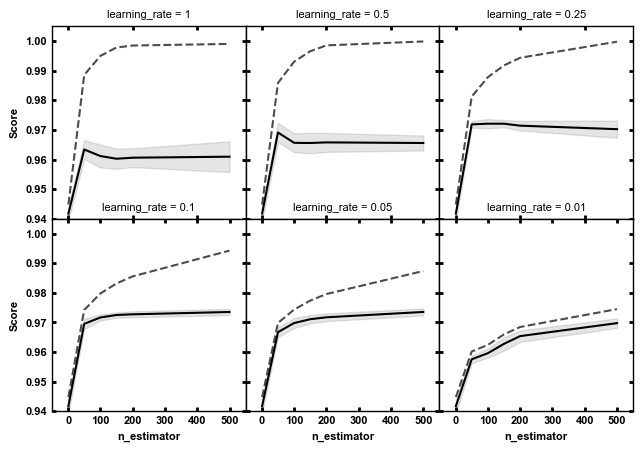

In [27]:
_set_global_font()

fig, axes = plt.subplots(2, 3, figsize=(7.5,  5), sharey=True, gridspec_kw={"wspace": 0, "hspace": 0})

X_axis = np.array(results["param_n_estimators"][:6], dtype=float)
scorer = 'AUC'
color = 'k'
for i in range(2):
    for j in range(3):
        index = i * 3 + j
        start = index * 6
        end = start + 6

        for sample, style in (("train", "--"), ("test", "-")):
            sample_score_mean = results["mean_%s_%s" % (sample, scorer)][start:end]
            sample_score_std = results["std_%s_%s" % (sample, scorer)][start:end]
            axes[i][j].fill_between(
                X_axis,
                sample_score_mean - sample_score_std,
                sample_score_mean + sample_score_std,
                alpha=0.1 if sample == "test" else 0,
                color=color,
            )
            axes[i][j].plot(
                X_axis,
                sample_score_mean,
                style,
                color=color,
                alpha=1 if sample == "test" else 0.7,
                label="%s (%s)" % (scorer, sample),
            )
        axes[i][j].set_ylim(0.94, 1.005)
        axes[i][j].set_xlim(-50, 550)
        axes[i][j].set_title(f'learning_rate = {lr[index]}')
        axes[i][j].tick_params(axis='both', direction='in', length=3, width=2)
        if i == 1:
            axes[i][j].set_xlabel('n_estimator')
            axes[i][j].set_xticks([0, 100, 200, 300, 400, 500])
        
        if j == 0:
            axes[i][j].set_ylabel('Score')

plt.savefig('Figure_S3.pdf', dpi=600, format="pdf", bbox_inches='tight')
plt.show()

### Figure S4. Systematic Feature Selection and Validation of the Reduced Dimensionality Model

In [38]:
def get_acuracy(x_data, y_data, model):
    x_train, x_test, y_train, y_test = train_test_split(x_data,  y_data, test_size=0.2, random_state=523)
    min_max_scaler = MinMaxScaler() 
    min_max_scaler.fit(x_train)   
    x_train = min_max_scaler.transform(x_train)
    x_test = min_max_scaler.transform(x_test)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    return accuracy_score(y_test, y_pred)

def get_clean_GBC():
    gb_iSmall = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=5, subsample=0.8, min_samples_leaf=4, max_features=0.9, random_state=523)
    gb_iMedium = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=5, subsample=0.6, min_samples_leaf=4, max_features=0.8, random_state=523)
    gb_iLarge = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=5, subsample=0.7, min_samples_leaf=4, max_features=0.6, random_state=523)
    return gb_iSmall, gb_iMedium, gb_iLarge

In [ ]:
data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'ablation_study.csv')
ablation_study = pd.read_csv(data_path)
ab = ablation_study.rename(columns={'0':'small_AUC', '1':'small_accuracy', '2':'med_AUC', '3':'med_accuracy', '4':'large_AUC', '5':'large_accuracy'})

### Model trained with 153 features
gb_iSmall, gb_iMedium, gb_iLarge = get_clean_GBC()

feat_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'pre_selection_features.pkl')
with open(feat_path, 'rb') as f:
    (X_small, labels_s, X_medium, labels_m, X_large, labels_l) = pickle.load(f)

accuracies = []
for i in range(3):
    if i == 0:
        acc = get_acuracy(X_small, labels_s, gb_iSmall)
    elif i == 1:
        acc = get_acuracy(X_medium, labels_m, gb_iMedium)
    else:
        acc = get_acuracy(X_large, labels_l, gb_iLarge)
    accuracies.append(acc)

ab_imp_l = abs(ab['large_accuracy'] - 1).to_list()
fi_imp_l = gb_iLarge.feature_importances_
ab_imp_m = abs(ab['med_accuracy'] - 1).to_list()
fi_imp_m = gb_iMedium.feature_importances_
ab_imp_s = abs(ab['small_accuracy'] - 1).to_list()
fi_imp_s = gb_iSmall.feature_importances_

df_ab = pd.DataFrame([ab_imp_s, ab_imp_m, ab_imp_l])
df_ab.index = ['AA_iSmall', 'AA_iMedium', 'AA_iLarge']

df_fi = pd.DataFrame([fi_imp_s, fi_imp_m, fi_imp_l])
df_fi.index = ['FI_iSmall', 'FI_iMedium', 'FI_iLarge']

In [45]:
### Reduced models with top 10 features in common across all three datasets
gb_iSmall, gb_iMedium, gb_iLarge = get_clean_GBC()
selected_features = set(np.argsort(fi_imp_s)[-10:]) & set(np.argsort(fi_imp_m)[-10:]) & set(np.argsort(fi_imp_l)[-10:])
new_accuracies = []
for i in range(3):
    if i == 0:
        acc = get_acuracy(X_small[:, list(selected_features)], labels_s, gb_iSmall)
    elif i == 1:
        acc = get_acuracy(X_medium[:, list(selected_features)], labels_m, gb_iMedium)
    else:
        acc = get_acuracy(X_large[:, list(selected_features)], labels_l, gb_iLarge)
    new_accuracies.append(acc)

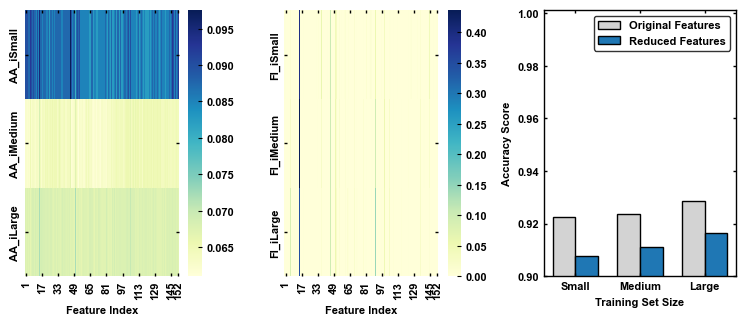

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.3))

_set_global_font()

ticks = list(range(1, len(df_ab.iloc[0, :]), 16))

last_idx = len(df_ab.iloc[0, :]) - 1
if ticks[-1] != last_idx:
    ticks.append(last_idx)

labels = [df_ab.columns[i] for i in ticks] 

# Heatmap 1: Ablation Study
sns.heatmap(df_ab, cmap='YlGnBu', ax=axes[0])
#axes[0].set_ylabel('Importance Score')
axes[0].yaxis.set_label_position('right')
axes[0].set_xlabel('Feature Index')
#axes[0].set_title('Ablation Analysis')
axes[0].set_xticks(ticks, labels=labels)
plt.setp(axes[0].get_yticklabels(), rotation=90) # Keep labels horizontal
axes[0].tick_params(axis="both", which="major", labelsize=8, length=2, width=1, direction="in",
        bottom=True, left=True)

# Heatmap 2: Feature Importance
sns.heatmap(df_fi, cmap='YlGnBu', ax=axes[1])
axes[1].set_ylabel('') # Keep left side clean
axes[1].yaxis.set_label_position('right')
axes[1].set_xlabel('Feature Index')
#axes[1].set_title('Feature Importance')
axes[1].set_xticks(ticks, labels=labels)
plt.setp(axes[1].get_yticklabels(), rotation=90)
axes[1].tick_params(axis="both", which="major", labelsize=8, length=2, width=1, direction="in",
        bottom=True, left=True,)

labels = ['Small', 'Medium', 'Large']
x = np.arange(len(labels))
width = 0.35
axes[2].bar(x - width/2, accuracies, width, label='Original Features', 
                color='lightgray', edgecolor='black', linewidth=1)
axes[2].bar(x + width/2, new_accuracies, width, label='Reduced Features', 
                color='tab:blue', edgecolor='black', linewidth=1)

axes[2].set_ylim(0.90, 1.001)
axes[2].set_ylabel('Accuracy Score', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel("Training Set Size")
axes[2].legend(loc='upper right', frameon=True, edgecolor='black')
axes[2].tick_params(axis="both", which="major", labelsize=8, length=2, width=1, direction="in",
        bottom=True, left=True, right=True, top=True)


plt.tight_layout()
plt.savefig("Figure_S4.pdf",
    dpi=600,
    format="pdf",
    bbox_inches="tight")
plt.show()

### Figure 5. Performance Comparison Between the Rolling-window GBC and RNN Model

In [ ]:
### RNN Classifier and Early Exit Evaluation Code (for Figure 5)
class SeqDataset(Dataset):
    def __init__(self, X, y, train_mode=False, max_seq_len=None):
        self.X = X
        self.y = y
        self.train_mode = train_mode
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        # Convert to float32 tensor
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        
        return x, y

def collate_pad(batch):
    """
    Pads variable length sequences in a batch to the length of the difficultest sequence.
    """
    xs, ys = zip(*batch)
    # This pads sequences with 0s at the end to make them equal length
    xs_padded = torch.nn.utils.rnn.pad_sequence(xs, batch_first=True, padding_value=0.0)
    ys = torch.stack(ys)
    return xs_padded, ys

@dataclass
class Config:
    feat_dim: int = 17
    hidden: int = 128
    bidir: bool = False
    dropout: float = 0.2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 50
    patience: int = 7

    # NEW:
    window_size: int = 10      # length of rolling window
    window_stride: int = 1     # slide by 1 timestep
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 523
    pos_weight: float | None = None

CFG = Config()

class GRUClassifier(nn.Module):
    def __init__(self, feat_dim, hidden, bidir=False, dropout=0.2, n_classes=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=feat_dim,
            hidden_size=hidden,
            batch_first=True,
            bidirectional=bidir,
        )
        out_dim = hidden * (2 if bidir else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, 1 if n_classes == 2 else n_classes)
        self.n_classes = n_classes
        self.bidir = bidir

    def forward(self, x):
        # x: (B, W, F)
        out, h = self.gru(x)  # h: (num_layers * num_directions, B, H)
        if self.bidir:
            h_last = torch.cat([h[-2], h[-1]], dim=1)
        else:
            h_last = h[-1]
        z = self.dropout(h_last)
        logits = self.fc(z)
        return logits.squeeze(-1)  # (B,)

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for xb, yb in loader:
        xb = xb.to(CFG.device)
        logits = model(xb)
        proba = torch.sigmoid(logits).cpu().numpy()
        probs.append(proba)
        ys.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(ys)

def step_metrics(y_true, y_proba, thr=0.5):
    y_pred = (y_proba >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else float('nan')
    acc = accuracy_score(y_true, y_pred)
    return dict(precision=prec, recall=rec, f1=f1, auc=auc, acc=acc)

def eval_by_prefix_new(model, X, y, steps, meta_file, thr=None, special=False):
    """Evaluate metrics when only first K steps are available (with cumulative early-exit)."""
    # Load meta once
    with open(meta_file) as f:
        meta = json.load(f)
    if thr is None:
        thr = meta.get("threshold", 0.5)

    mean = np.array(meta["scaler"]["mean"]) if meta["scaler"]["mean"] is not None else None
    std  = np.array(meta["scaler"]["std"])  if meta["scaler"]["std"]  is not None else None

    def transform_list(X_list):
        if mean is None or std is None:
            return X_list
        out = []
        for arr in X_list:
            out.append(((arr - mean) / std).astype(np.float32))
        return out

    results = {}
    num_samples = len(y)

    active_count = {}
    
    # --- EARLY EXIT TRACKERS ---
    # locked_mask keeps track of molecules that have been flagged as 1 (Hard)
    locked_mask = np.zeros(num_samples, dtype=bool)
    
    # cumulative_probs stores the active probability, freezing it once a sample is locked
    cumulative_probs = np.zeros(num_samples, dtype=np.float32)

    for K in steps:
        # 1. Prepare data truncated to K
        XK = [arr[:K] for arr in X]                 
        XK = transform_list(XK)                     
        
        ds = SeqDataset(XK, y, train_mode=False, max_seq_len=K)
        dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=False, collate_fn=collate_pad)

        # 2. Get raw predictions for this current step
        proba, yy = predict_proba(model, dl)
        
        # 3. --- EARLY EXIT LOGIC ---
        # Identify samples that are still running (not yet locked)
        active_mask = ~locked_mask
        
        # Update probabilities ONLY for active cases
        cumulative_probs[active_mask] = proba[active_mask]
        
        # Find cases that JUST crossed the threshold to be flagged as 'Hard' (1)
        just_triggered = active_mask & (proba >= thr)
        
        # Lock them so their probability (and prediction) is frozen for all future K
        locked_mask[just_triggered] = True
        # ---------------------------
        
        # 4. Record Metrics based on the cumulative state
        if special:
            avg_proba = np.mean(cumulative_probs)
            # How many are locked as positive by this step?
            pos_rate = np.mean(cumulative_probs >= thr) 
            print(f"Step {K}: Avg Confidence: {avg_proba:.4f} | % Flagged as Positive: {pos_rate*100:.1f}%")
        else:
            # step_metrics will threshold cumulative_probs and calculate AUC/F1/Precision/Recall
            results[K] = step_metrics(yy, cumulative_probs, thr=thr)
            
            active_easy = np.sum(active_mask & (y == 0))
            active_difficult = np.sum(active_mask & (y == 1))
            active_count[K] = [active_easy, active_difficult] 
            
    return None if special else (results, active_count)

def normalize_features(X, feat_min, feat_max):
    """Feature-wise min-max normalization with clipping for safety."""
    X_norm = (X - feat_min) / (feat_max - feat_min)
    return np.clip(X_norm, 0, 1)

def evaluate_early_exit_curves(gb_model, perK_feats, y_true, steps, feat_max, feat_min, thr=0.5):
    num_samples = len(y_true)
    
    # Track cumulative predictions (0 = still running/Easy, 1 = flagged as Hard)
    # Everyone starts as 0. Once flagged as 1, they stay 1 and are not evaluated again.
    cumulative_preds = np.zeros(num_samples, dtype=int)

    active_count = {}
    
    # To calculate AUC, we can track the maximum probability seen so far for each sample
    cumulative_probs = np.zeros(num_samples, dtype=float)
    
    curves = {"AUC": {}, "F1": {}, "Precision": {}, "Recall": {}}
    
    for K in steps:
        XK = perK_feats[K]                # (N, 6)
        
        # 1. Identify which molecules are STILL RUNNING (haven't been flagged yet)
        active_mask = (cumulative_preds == 0)
        active_indices = np.where(active_mask)[0]
        
        if len(active_indices) > 0:
            # 2. Extract features ONLY for the active molecules
            XK_active = XK[active_indices]
            
            # Check for NaNs
            valid_feat_mask = np.all(np.isfinite(XK_active), axis=1)
            valid_indices = active_indices[valid_feat_mask]
            
            if len(valid_indices) > 0:
                XK_valid = XK[valid_indices]
                
                # 3. Normalize and Predict
                XK_norm = normalize_features(XK_valid, feat_min, feat_max)
                probs = gb_model.predict_proba(XK_norm)[:, 1]
                
                # 4. Update the cumulative states
                # Update max probabilities seen so far
                cumulative_probs[valid_indices] = np.maximum(cumulative_probs[valid_indices], probs)
                
                # Flag molecules that crossed the threshold
                newly_flagged = (probs >= thr).astype(int)
                cumulative_preds[valid_indices] = newly_flagged
                
        # 5. Calculate metrics based on the CUMULATIVE state up to step K
        # By step K, what is the total F1, Precision, and Recall of our intervention?
        f1   = f1_score(y_true, cumulative_preds, zero_division=0)
        prec = precision_score(y_true, cumulative_preds, zero_division=0)
        rec  = recall_score(y_true, cumulative_preds, zero_division=0)
        
        try:
            auc = roc_auc_score(y_true, cumulative_probs)
        except ValueError:
            auc = np.nan

        curves["AUC"][K]       = auc
        curves["F1"][K]        = f1
        curves["Precision"][K] = prec
        curves["Recall"][K]    = rec

        # How many Easy cases are still active?
        active_easy = len(np.where(y_true[active_indices] == 0)[0])
        # How many Hard cases are still active?
        active_hard = len(np.where(y_true[active_indices] == 1)[0])
        
        active_count[K] = [active_easy, active_hard]
        
    return (curves, active_count)

In [88]:
gbc_model_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'iMedium_model.pkl')
with open(gbc_model_path, 'rb') as file:
    gbc_iMedium = pickle.load(file)

rnn_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'rnn_data_iMedium.pkl')
with open(rnn_data_path, "rb") as file:
    [medium_rnn_train, medium_rnn_test, medium_rnn_y_train, medium_rnn_y_test] = pickle.load(file)

rnn_model_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'rnn_model_iMedium.pkl')
with open(rnn_model_path, 'rb') as file:
    rnn_med = pickle.load(file)

iMedium_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_med_xtest_xval.pkl')
with open(iMedium_data_path, "rb") as file:
    [X_test_m, X_val_m, y_test_m, y_val_m] = pickle.load(file)

rolling_window_info = os.path.join(Path.cwd().parents[0], 'notebook_data', 'rolling_window_info.pkl')
with open(rolling_window_info, 'rb') as f:
    (small_data, med_data, large_data) = pickle.load(f)

idx_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_med_test_val_idx.pkl')
with open(idx_path, 'rb') as f:
    idx_test, idx_val = pickle.load(f)

label_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'iMedium_labels.pkl')
with open(label_path, 'rb') as f:
    y_iMedium = pickle.load(f)

meta_file_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'rnn_gru_meta_iMedium.json')

##iMedium training set min and max values for the 6 features
med_max = np.array([4, 0.08411743, 7, -0.08268854, 0.01957704, 0.29705262])
med_min = np.array([0, -0.23644108, 1, -0.37858158, -0.36029886, 0.03714591])


true_iMedium_test_rnn = [medium_rnn_test[i] for i in idx_test]
true_iMedium_y_test_rnn = np.array([medium_rnn_y_test[i] for i in idx_test])

steps = range(11,31)

true_iMedium_test_gbc = {}

for i in range(len(med_data)):
    counter = 11 + i
    iter_info = med_data.get(counter)
    true_test = np.array([iter_info[i] for i in idx_test])
    true_iMedium_test_gbc[counter] = true_test

true_iMedium_y_test_gbc = np.array([y_iMedium[i] for i in idx_test])

In [89]:
prefix_results, active_rnn_cases= eval_by_prefix_new(rnn_med, true_iMedium_test_rnn, true_iMedium_y_test_rnn, steps=np.linspace(10, 29, 20, dtype=int), meta_file=meta_file_path, thr=0.802)

AUC = []
f1s = []
precisions = []
recalls = []
n_steps = []
for K, m in prefix_results.items():
    AUC.append(m['auc'])
    f1s.append(m['f1'])
    precisions.append(m['precision'])
    recalls.append(m['recall'])
    n_steps.append(K)

gb_curves_med_tst, active_cases = evaluate_early_exit_curves(gbc_iMedium, true_iMedium_test_gbc, true_iMedium_y_test_gbc, steps, med_max, med_min, thr=0.802)

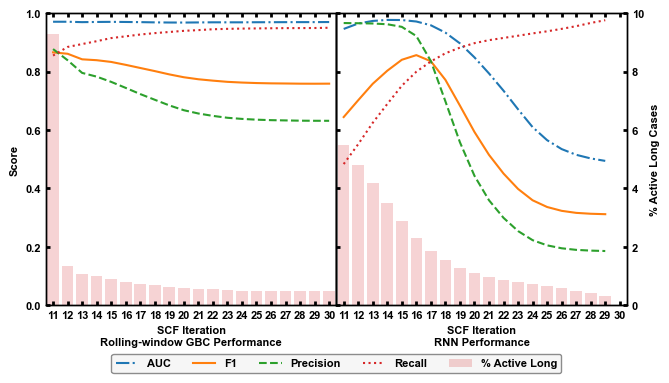

In [ ]:
_set_global_font()

auc_dict = gb_curves_med_tst['AUC']
f1_dict = gb_curves_med_tst['F1']
prec_dict = gb_curves_med_tst['Precision']
recall_dict = gb_curves_med_tst['Recall']

x = np.array(sorted(auc_dict.keys()))
auc_y    = np.array([auc_dict[k] for k in x])
f1_y     = np.array([f1_dict.get(k, np.nan) for k in x])
prec_y   = np.array([prec_dict.get(k, np.nan) for k in x])
recall_y = np.array([recall_dict.get(k, np.nan) for k in x])
active_status = np.array([active_cases.get(k, np.nan) for k in x])
difficult_percent = np.array([active_status[i][1]*100/len(medium_rnn_y_test) for i in range(len(active_status))])

x_rnn = np.asarray(n_steps)
active_status_rnn = np.array([active_rnn_cases.get(k, np.nan) for k in x_rnn])
difficult_percent_rnn = np.array([active_status_rnn[i][1]*100/len(medium_rnn_y_test) for i in range(len(active_status_rnn))])

# Determine the maximum value for the bar charts to set a consistent right-axis scale
# If the lists are fractions (0.0 to 1.0), you can just set y_max = 1.0
max_bar_val = max(max(difficult_percent), max(difficult_percent_rnn))

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4), sharey=True, gridspec_kw={"wspace": 0, "hspace": 0}) 

# ==========================================
# 1. Setup Secondary Axes for Bar Charts
# ==========================================
ax0_bar = axes[0].twinx()
ax1_bar = axes[1].twinx()

# Plot the bars (alpha=0.2 makes them faded/transparent)
ax0_bar.bar(x, difficult_percent, color='tab:red', alpha=0.2, width=0.8, label='% Active difficult')
ax1_bar.bar(x_rnn[1:], difficult_percent_rnn[1:], color='tab:red', alpha=0.2, width=0.8, label='% Active difficult')

# Align the Y-limits for the secondary axes
ax0_bar.set_ylim(0, 10)
ax1_bar.set_ylim(0, 10)

# Hide the Y-ticks on the left bar axis so it doesn't overlap the right subplot
ax0_bar.yaxis.set_visible(False)

# Format the Y-ticks on the right bar axis
ax1_bar.set_ylabel('% Active difficult Cases')
ax1_bar.tick_params(axis='y', direction='in', length=3, width=2)

# ==========================================
# 2. Plot Lines on Primary Axes
# ==========================================
axes[0].plot(x, auc_y,    linestyle='-.', label='AUC')
axes[0].plot(x, f1_y,     linestyle='-', label='F1')
axes[0].plot(x, prec_y,   linestyle='--', label='Precision')
axes[0].plot(x, recall_y, linestyle=':', label='Recall')

axes[0].set_xlim(10.5, 30.5)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_xticks(x)
axes[0].tick_params(direction='in', length=3, width=2)
axes[0].set_xlabel('SCF Iteration\nRolling-window GBC Performance')
axes[0].set_ylabel('Score')

axes[1].plot(x_rnn[1:], AUC[1:], linestyle='-.', label='AUC')
axes[1].plot(x_rnn[1:], f1s[1:], linestyle='-', label='F1')
axes[1].plot(x_rnn[1:], precisions[1:], linestyle='--',  label='Precision')
axes[1].plot(x_rnn[1:], recalls[1:], linestyle=':', label='Recall')

axes[1].set_xlim(10.5, 30.5)
axes[1].set_xticks(x)
axes[1].tick_params(direction='in', length=3, width=2)
axes[1].set_xlabel('SCF Iteration\nRNN Performance')

# ==========================================
# 3. Layering Fix (Lines over Bars)
# ==========================================
# Force the primary axes (lines) to be drawn ON TOP of the secondary axes (bars)
axes[0].set_zorder(ax0_bar.get_zorder() + 1)
axes[0].patch.set_visible(False)  # Make primary axis background transparent

axes[1].set_zorder(ax1_bar.get_zorder() + 1)
axes[1].patch.set_visible(False)

# ==========================================
# 4. Legend Assembly
# ==========================================
# Get handles from primary lines
handles, labels = axes[0].get_legend_handles_labels()
# Get handle from the bar chart
bar_handles, bar_labels = ax0_bar.get_legend_handles_labels()

# Combine them (changing ncol to 5 to fit the new metric)
legend = plt.legend(
    handles + bar_handles, 
    labels + bar_labels,
    loc='center',             
    bbox_to_anchor=(0, -0.2), # shifted slightly lower to accommodate extra text
    ncol=5,                    # 5 items total
    frameon=True
)

# Styling the legend box
legend.get_frame().set_facecolor('whitesmoke')
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_alpha(0.9)

plt.subplots_adjust(bottom=0.15) # Increase bottom margin for 5-column legend

plt.savefig('Figure_S5.pdf', dpi=600, format="pdf", bbox_inches='tight')
plt.show()

### Figure S6. Confusion Matrix of the GBC Models Evaluated on the iSmall-test, iMedium-test, and iLarge-test Without Decision Threshold Tuning

In [93]:
# -------------------------------
# Function to predict with threshold
# -------------------------------
def predict_with_threshold(model, X, thr):
    pos_index = int(np.where(model.classes_ == 1)[0][0])
    p = model.predict_proba(X)[:, pos_index]
    return (p >= thr).astype(int), p

gbc_iSmall_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'iSmall_model.pkl')
gbc_iMedium_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'iMedium_model.pkl')
gbc_iLarge_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'iLarge_model.pkl')
iSmall_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_small_xtest_xval.pkl')
iMedium_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_med_xtest_xval.pkl')
iLarge_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_large_xtest_xval.pkl')

with open(gbc_iSmall_path, 'rb') as file:
    gbc_iSmall = pickle.load(file)
with open(gbc_iMedium_path, 'rb') as file:
    gbc_iMedium = pickle.load(file)
with open(gbc_iLarge_path, 'rb') as file:
    gbc_iLarge = pickle.load(file)
with open(iSmall_data_path, "rb") as file:
    [X_test_s, X_val_s, y_test_s, y_val_s] = pickle.load(file)
with open(iMedium_data_path, "rb") as file:
    [X_test_m, X_val_m, y_test_m, y_val_m] = pickle.load(file)
with open(iLarge_data_path, "rb") as file:
    [X_test_l, X_val_l, y_test_l, y_val_l] = pickle.load(file)

# iSmall
y_pred_s, p_s = predict_with_threshold(gbc_iSmall, X_test_s, 0.5)
f1_s = f1_score(y_test_s, y_pred_s)
cm   = confusion_matrix(y_test_s, y_pred_s)

# iMedium
y_pred_m, p_m = predict_with_threshold(gbc_iMedium,  X_test_m, 0.5)
f1_m = f1_score(y_test_m, y_pred_m)
cm_2 = confusion_matrix(y_test_m, y_pred_m)

# iLarge
y_pred_l, p_l = predict_with_threshold(gbc_iLarge, X_test_l, 0.5)
f1_l = f1_score(y_test_l, y_pred_l)
cm_3 = confusion_matrix(y_test_l, y_pred_l)

print("CM (iSmall @ 0.5):\n", cm)
print("CM_2 (iSed @ 0.5):\n", cm_2)
print("CM_3 (iLarge @ 0.5):\n", cm_3)

CM (iSmall @ 0.5):
 [[42950  2930]
 [ 1311 10694]]
CM_2 (iSed @ 0.5):
 [[40857  3023]
 [  877  9128]]
CM_3 (iLarge @ 0.5):
 [[39005  2375]
 [  688  6817]]


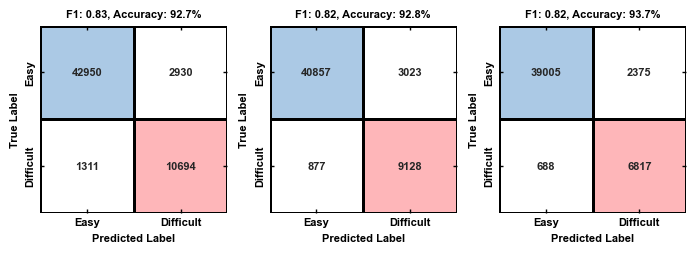

In [97]:
class_names = ["Easy", "Difficult"]

# --- define colors ---
TN_COLOR = "#abc9e5"   # top-left
TP_COLOR = "#feb6b9"   # bottom-right
OFF_COLOR = "#ffffff"  # for FP and FN (off-diagonal)

# indices: 0 = TN, 1 = FP, 2 = FN, 3 = TP
color_idx = np.array([[0, 1],
                      [2, 3]])

cmap = ListedColormap([TN_COLOR, OFF_COLOR, OFF_COLOR, TP_COLOR])
norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(7, 3.3))

# ---- Small ----
sns.heatmap(
    color_idx,
    annot=cm, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[0], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black'
)
axes[0].set_title(f"F1: {f1_s:.2f}, Accuracy: {cm.trace() / cm.sum() * 100:.1f}%", fontweight='bold')
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

# ---- Medium ----
sns.heatmap(
    color_idx,
    annot=cm_2, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[1], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black'
)
axes[1].set_title(f"F1: {f1_m:.2f}, Accuracy: {cm_2.trace() / cm_2.sum() * 100:.1f}%", fontweight='bold')
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

# ---- Large ----
sns.heatmap(
    color_idx,
    annot=cm_3, fmt='d',
    cmap=cmap, norm=norm,
    cbar=False, ax=axes[2], square=True,
    xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='black'
)

axes[2].set_title(f"F1: {f1_l:.2f}, Accuracy: {cm_3.trace() / cm_3.sum() * 100:.1f}%", fontweight='bold')
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")
axes[2].tick_params(axis='both', which='major', width=1, direction='in',
                    left=True, bottom=True, top=True, right=True)

plt.tight_layout()
plt.savefig("Figure_S6.pdf", dpi=600, bbox_inches='tight')
plt.show()

### Figure S7. Ten-fold Cross-validation Receiver Operating Characteristic (ROC) Curves for GBC Trained on Various Training Set Sizes

In [99]:
def plot_mean_roc_panel(ax, fprs_list, tprs_list, aucs_list, color, panel_label=None):
    """
    fprs_list, tprs_list: list of arrays (one per fold)
    aucs_list: list/array of AUC values (one per fold)
    """

    _set_global_font()

    # Common FPR grid for interpolation
    mean_fpr = np.linspace(0.0, 1.0, 200)

    tprs_interp = []

    for fpr, tpr in zip(fprs_list, tprs_list):
        # individual fold ROC (light gray)
        ax.plot(fpr, tpr, lw=0.8, alpha=0.3, color="0.7")

        # interpolate onto common grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs_interp.append(interp_tpr)

    tprs_interp = np.array(tprs_interp)
    mean_tpr = tprs_interp.mean(axis=0)
    std_tpr  = tprs_interp.std(axis=0)
    mean_tpr[-1] = 1.0  # ensure it ends at 1

    mean_auc = np.mean(aucs_list)
    std_auc  = np.std(aucs_list)

    # Mean ROC curve
    ax.plot(mean_fpr, mean_tpr, color=color, label=f"Mean ROC\n(AUC = {mean_auc:.2f} ± {std_auc:.2f})")

    # Shaded ±1 std band
    ax.fill_between(
        mean_fpr,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        color=color,
        alpha=0.25,
        linewidth=0,
    )

    # Random-guess diagonal
    ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1)

    # Axes formatting
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("False Positive Rate")
    ax.tick_params(
        axis="both", which="major", width=2, direction="in",
        bottom=True, top=True, left=True, right=True,
    )

    # Legend (inside, bottom-right)
    legend = ax.legend(
        loc="lower right",
        frameon=True
    )
    legend.get_frame().set_facecolor("none")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.5)

    # Borders
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

    if panel_label is not None:
        ax.set_title(panel_label, fontweight="bold")

In [101]:
kfold_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'gb_kfold_infos.pkl')
with open(kfold_path, "rb") as file:
    [fprs, tprs, aucs, accuracies, fprs_2, tprs_2, aucs_2, accuracies_2, fprs_3, tprs_3, aucs_3, accuracies_3] = pickle.load(file)

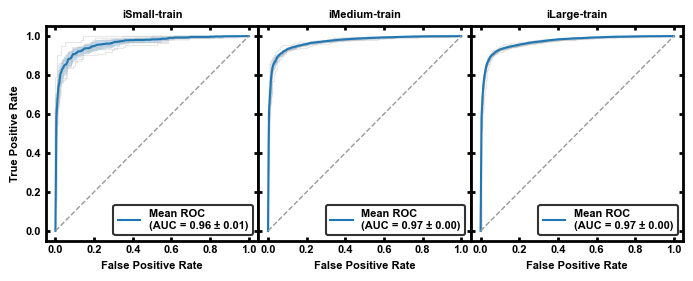

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2.85), sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0})

# Left panel: small train
ax = axes[0]
plot_mean_roc_panel(ax, fprs_3, tprs_3, aucs_3, color="tab:blue", panel_label="iSmall-train")
ax.set_ylabel("True Positive Rate")

# Middle panel: medium train
ax = axes[1]
plot_mean_roc_panel(ax, fprs_2, tprs_2, aucs_2, color="tab:blue", panel_label="iMedium-train")

# Right panel: large train
ax = axes[2]
plot_mean_roc_panel(ax, fprs, tprs, aucs, color="tab:blue", panel_label="iLarge-train")

plt.tight_layout()
plt.savefig(
    "Figure_S7.pdf",
    dpi=600,
    format="pdf",
    bbox_inches="tight",
)
plt.show()

### Figure S8. Frontier Orbital Energy Profiles Averaged Over the First 30 SCF Iterations for the Six Test Domains.

In [111]:
def plot_frontier_ladders_both_spin(
    alpha_arrays,         # dict[str, np.ndarray]
    beta_arrays,          # dict[str, np.ndarray]
    alpha_names,          # list[str] names for alpha x-axis
    beta_names,           # list[str] names for beta x-axis
    labels,               # dict[str, np.ndarray], 0=easy, 1=difficult
    domains_to_plot=None, 
    save=False,
    outpath=None
):
    if domains_to_plot is None:
        domains_to_plot = list(alpha_arrays.keys())

    # --- 1. Prepare Data ---
    # Structure: processed[domain][spin][type]
    processed_data = {}
    for d in domains_to_plot:
        lab = np.asarray(labels[d])
        mask_easy = (lab == 0)
        mask_difficult  = (lab == 1)
        
        processed_data[d] = {
            'alpha': {'easy': alpha_arrays[d][mask_easy], 'difficult': alpha_arrays[d][mask_difficult]},
            'beta':  {'easy': beta_arrays[d][mask_easy],  'difficult': beta_arrays[d][mask_difficult]}
        }

    # --- 2. Setup Figure ---
    # 2x2 Grid. 
    fig, axes = plt.subplots(
        2, 2,
        figsize=(7.5, 5),
        sharex='col', 
        sharey='all', # Force all panels to share Y-axis for direct energy comparison
        gridspec_kw={"wspace": 0, "hspace": 0}
    )
    
    _set_global_font()

    # Unpack axes: 
    # (Alpha easy, Beta easy)
    # (Alpha difficult,  Beta difficult)
    ((ax_alpha_easy, ax_beta_easy), (ax_alpha_difficult, ax_beta_difficult)) = axes

    try:
        _set_global_font() 
    except NameError:
        pass 

    colors = sns.color_palette("deep", n_colors=len(domains_to_plot))
    color_map = {d: c for d, c in zip(domains_to_plot, colors)}

    # Define Plot Configurations
    # Format: (Spin Key, Type Key, Axis, Feature Names, Row Label (optional))
    plots = [
        ('alpha', 'easy', ax_alpha_easy, alpha_names, "easy (Easy)"),
        ('beta',  'easy', ax_beta_easy,  beta_names,  None),
        ('alpha', 'difficult',  ax_alpha_difficult,  alpha_names, "difficult (Hard)"),
        ('beta',  'difficult',  ax_beta_difficult,   beta_names,  None)
    ]

    # --- 3. Plotting Loop ---
    for spin_key, type_key, ax, feat_names, row_label in plots:
        
        # Add Row Label to Left Column only
        for domain in domains_to_plot:
            subset = processed_data[domain][spin_key][type_key]
            if len(subset) == 0: continue

            mean = subset.mean(axis=0)
            std  = subset.std(axis=0)
            
            ax.plot(feat_names, mean, marker="o", markersize=3, label=domain, color=color_map[domain])
            
            ax.fill_between(feat_names, mean - std, mean + std, 
                            color=color_map[domain], alpha=0.15)

    # --- 4. Formatting ---

    for ax in axes.flat:
        ax.tick_params(direction='in', width=1, labelsize=10)
        #ax.grid(True, linestyle='--', alpha=0.4)
        for spine in ax.spines.values():
            spine.set_linewidth(1)
            spine.set_edgecolor("black")

    # Y-Labels (Left Column Only)
    ax_alpha_easy.set_ylabel("Orbital Energy for\n'easy' Molecules (a.u.)", fontweight='bold')
    ax_alpha_difficult.set_ylabel("Orbital Energy for\n'difficult' Molecules (a.u.)", fontweight='bold')

    # X-Labels (Bottom Row Only)
    # Rotate names to fit
    # explicitly set the locations first
    ax_alpha_difficult.set_xticks(range(len(alpha_names)))
    ax_alpha_difficult.set_xticklabels(alpha_names, rotation=45, ha='right', fontweight='bold')

    # explicitly set the locations first
    ax_beta_difficult.set_xticks(range(len(beta_names)))
    ax_beta_difficult.set_xticklabels(beta_names, rotation=45, ha='right', fontweight='bold')
    
    # Legend (Bottom Right Plot, inside)
    ax_beta_easy.legend(
        loc='lower right', fontsize=8, frameon=True, 
        title_fontsize=8
    )

    plt.tight_layout()
    
    if save:
        fig.savefig(outpath, format="pdf", dpi=600, bbox_inches="tight")
        print(f"Figure saved to {outpath}")
        
    plt.show()

In [112]:
domain_data_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'domain_data_median_first_30_iters.pkl')
with open(domain_data_path, 'rb') as f:
    domain_data = pickle.load(f)

y_labels_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'domain_labels.pkl')
with open(y_labels_path, 'rb') as f:
    (y_qm40, y_qm40_dft, y_qm9, y_qm9_basis, y_qm9_hcore, y_qm9_pyscf) = pickle.load(f)

qm40_all_feat = domain_data['qm40']
qm40_dft_all_feat = domain_data['qm40_dft']
qm9_all_feat = domain_data['qm9']
qm9_basis_all_feat = domain_data['qm9_basis']
qm9_hcore_all_feat = domain_data['qm9_hcore']
qm9_pyscf_all_feat = domain_data['qm9_pyscf']

qm40_frontier = qm40_all_feat[:, 2:14]
qm40_dft_frontier = qm40_dft_all_feat[:, 2:14]
qm9_frontier = qm9_all_feat[:, 2:14]
qm9_basis_frontier = qm9_basis_all_feat[:, 2:14]
qm9_hcore_frontier = qm9_hcore_all_feat[:, 2:14]
qm9_pyscf_frontier = qm9_pyscf_all_feat[:, 1:]

alpha_domains = {
    "iQM40-default":      qm40_frontier[:, 0:6],
    "iQM40-DFT":  qm40_dft_frontier[:, 0:6],
    "iQM9-default":       qm9_frontier[:, 0:6],
    "iQM9-larger-basis": qm9_basis_frontier[:, 0:6],
    "iQM9-hcore": qm9_hcore_frontier[:, 0:6],
    "iQM9-PySCF": qm9_pyscf_frontier[:, 0:6]
}


frontier_alpha_names = [
    r"$\varepsilon_{HOMO-2}^\alpha$",
    r"$\varepsilon_{HOMO-1}^\alpha$",
    r"$\varepsilon_{HOMO}^\alpha$",
    r"$\varepsilon_{LUMO}^\alpha$",
    r"$\varepsilon_{LUMO+1}^\alpha$",
    r"$\varepsilon_{LUMO+2}^\alpha$",
]

beta_domains = {
    "iQM40-default":      qm40_frontier[:, 6:],
    "iQM40-DFT":  qm40_dft_frontier[:, 6:],
    "iQM9-default":       qm9_frontier[:, 6:],
    "iQM9-larger-basis": qm9_basis_frontier[:, 6:],
    "iQM9-hcore": qm9_hcore_frontier[:, 6:],
    "iQM9-PySCF": qm9_pyscf_frontier[:, 6:]
}

frontier_beta_names = [
    r"$\varepsilon_{HOMO-2}^\beta$",
    r"$\varepsilon_{HOMO-1}^\beta$",
    r"$\varepsilon_{HOMO}^\beta$",
    r"$\varepsilon_{LUMO}^\beta$",
    r"$\varepsilon_{LUMO+1}^\beta$",
    r"$\varepsilon_{LUMO+2}^\beta$",
]

Figure saved to Figure_S8.pdf


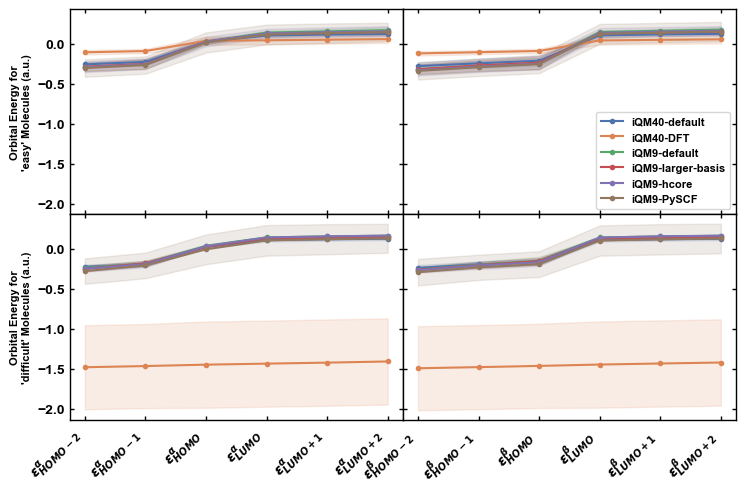

In [113]:
# 0 = easy, 1 = difficult, per domain
labels_dict = {
    "iQM40-default":      y_qm40,
    "iQM40-DFT":  y_qm40_dft,
    "iQM9-default":       y_qm9,
    "iQM9-larger-basis": y_qm9_basis,
    "iQM9-hcore": y_qm9_hcore,
    "iQM9-PySCF": y_qm9_pyscf
}

plot_frontier_ladders_both_spin(
    alpha_domains,
    beta_domains,
    frontier_alpha_names,
    frontier_beta_names,
    labels_dict,
    domains_to_plot=["iQM40-default", "iQM40-DFT", "iQM9-default", "iQM9-larger-basis", "iQM9-hcore", "iQM9-PySCF"],
    save=True,
    outpath = 'Figure_S8.pdf'
)

### Figure S9. Adaptive Level-Shifting Performance on "Intermediate" Cases

In [115]:
def density_scatter(x, y, ax, sort=True, bins=20, **kwargs):
    """
    Scatter plot colored by 2D kernel density estimate.
    """
    # Calculate the point density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # NORMALIZE: Scale z from 0 to 1 so colorbars match across plots
    z = z / z.max()

    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    sc = ax.scatter(x, y, c=z, **kwargs)
    return sc

In [116]:
intermediate_case_path = os.path.join(Path.cwd().parents[0], 'notebook_data', 'intermediate_cases_restart.csv')
medium_comp = pd.read_csv(intermediate_case_path)

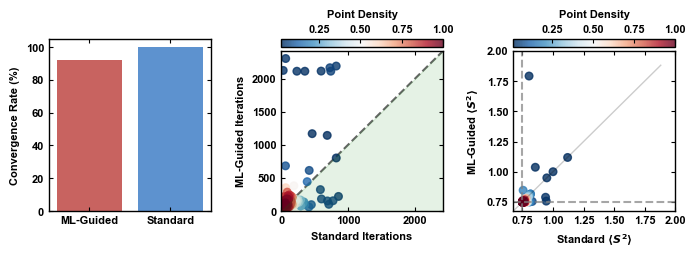

In [117]:
_set_global_font()

fig, axes = plt.subplots(1, 3, figsize=(7, 2.6))

# --- Plot 1: Convergence Rates (Bar Chart) ---
conv_x = medium_comp['converged_x'].mean() * 100
conv_y = medium_comp['converged_y'].mean() * 100

sns.barplot(
    x=['ML-Guided', 'Standard'], 
    y=[conv_x, conv_y], 
    ax=axes[0], 
    palette=['#D9534F', '#4A90E2'] # Slightly softer red/blue for publication
)
axes[0].set_ylabel('Convergence Rate (%)', fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].tick_params(direction='in', left=True, bottom=True, right=True, top=True)

# --- Plot 2: Iteration Efficiency (Density Scatter) ---
x_iter = medium_comp['iterations_y']
y_iter = medium_comp['iterations_x']

# Use the helper function to create a density scatter plot
sc1 = density_scatter(x_iter, y_iter, ax=axes[1], cmap='RdBu_r', s=30, alpha=0.8)

# Diagonal line (x=y)
max_val = max(x_iter.max(), y_iter.max())
lims = [0, max_val * 1.05]
axes[1].plot(lims, lims, 'k--', alpha=0.6, lw=1.5, zorder=0)

axes[1].set_xlabel('Standard Iterations', fontweight='bold')
axes[1].set_ylabel('ML-Guided Iterations', fontweight='bold')
axes[1].fill_between(lims, 0, lims, color='green', alpha=0.1, label='Acceleration Zone')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].tick_params(direction='in', left=True, bottom=True, right=True, top=True)

cbar1 = fig.colorbar(sc1, ax=axes[1], location='top', fraction=0.05, pad=0.02)
cbar1.set_label('Point Density', fontweight='bold', labelpad=5)
cbar1.ax.tick_params(labelsize=8)

# --- Plot 3: Spin Contamination (Density Scatter) ---
x_spin = medium_comp['s2_y']
y_spin = medium_comp['s2_x']

# Use the helper function again
sc2 = density_scatter(x_spin, y_spin, ax=axes[2], cmap='RdBu_r', s=30, alpha=0.8)

# Ideal doublet lines
axes[2].axhline(0.75, color='gray', linestyle='--', lw=1.5, alpha=0.7)
axes[2].axvline(0.75, color='gray', linestyle='--', lw=1.5, alpha=0.7)

# Diagonal reference
lims_spin = [min(x_spin.min(), y_spin.min())*0.9, max(x_spin.max(), y_spin.max())*1.05]
axes[2].plot(lims_spin, lims_spin, 'k-', alpha=0.2, lw=1) 

axes[2].set_xlabel(r'Standard $\langle S^2 \rangle$', fontweight='bold')
axes[2].set_ylabel(r'ML-Guided $\langle S^2 \rangle$', fontweight='bold')
axes[2].set_xlim(lims_spin)
axes[2].set_ylim(lims_spin)
axes[2].tick_params(direction='in', left=True, bottom=True, right=True, top=True)
axes[2].set_yticks([0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
axes[2].set_xticks([0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

cbar2 = fig.colorbar(sc2, ax=axes[2], location='top', fraction=0.05, pad=0.02)
cbar2.set_label('Point Density', labelpad=5, fontweight='bold',)
cbar2.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('Figure_S9.pdf', dpi=600, format="pdf", bbox_inches='tight')
plt.show()